In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

In [3]:
# Set pandas options to display all columns
pd.set_option('display.max_columns', None)

In [4]:
# Load dataset
df = pd.read_csv('Regulatory Affairs of Road Accident Data 2020 India (1).csv')
df

,Million Plus Cities,Cause category,Cause Subcategory,Outcome of Incident,Count
0,Agra,Traffic Control,Flashing Signal/Blinker,Greviously Injured,0.0
1,Agra,Traffic Control,Flashing Signal/Blinker,Minor Injury,0.0
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
3,Agra,Traffic Control,Flashing Signal/Blinker,Total Injured,0.0
4,Agra,Traffic Control,Flashing Signal/Blinker,Total number of Accidents,0.0
...,...,...,...,...,...
9545,Vizaq,Weather,Sunny/Clear,Greviously Injured,561.0
9546,Vizaq,Weather,Sunny/Clear,Minor Injury,252.0
9547,Vizaq,Weather,Sunny/Clear,Persons Killed,176.0
9548,Vizaq,Weather,Sunny/Clear,Total number of Accidents,1207.0


### --- Task 1: Initial Data Loading and Inspection (Adapted for available data) ---

In [5]:
print("--- Task 1: Initial Data Loading and Inspection (Adapted for available data) ---")

--- Task 1: Initial Data Loading and Inspection (Adapted for available data) ---


In [6]:
# Display the first 5 rows of the DataFrame
print("\nDataFrame Head:")
print(df.head())


DataFrame Head:
  Million Plus Cities   Cause category        Cause Subcategory  \
0                Agra  Traffic Control  Flashing Signal/Blinker   
1                Agra  Traffic Control  Flashing Signal/Blinker   
2                Agra  Traffic Control  Flashing Signal/Blinker   
3                Agra  Traffic Control  Flashing Signal/Blinker   
4                Agra  Traffic Control  Flashing Signal/Blinker   

         Outcome of Incident  Count  
0         Greviously Injured    0.0  
1               Minor Injury    0.0  
2             Persons Killed    0.0  
3              Total Injured    0.0  
4  Total number of Accidents    0.0  


In [7]:
# Check data shape
print("\nData Shape:")
print(df.shape)
print(f"The DataFrame has {df.shape[0]} rows and {df.shape[1]} columns.")


Data Shape:
(9550, 5)
The DataFrame has 9550 rows and 5 columns.


In [8]:
# Check for duplicated data
print("\nDuplicated Data Count:")
print(f'Number of duplicated data: {df.duplicated().sum()}')


Duplicated Data Count:
Number of duplicated data: 0


In [9]:
# Check missing values
print("\nMissing Values (Percentage):")
print((df.isnull().sum() / len(df)) * 100)
print("Based on the provided CSV, there are no missing values in these columns.")


Missing Values (Percentage):
Million Plus Cities    0.000000
Cause category         0.000000
Cause Subcategory      0.000000
Outcome of Incident    0.000000
Count                  0.031414
dtype: float64
Based on the provided CSV, there are no missing values in these columns.


In [10]:
# Check data types
print("\nData Types:")
print(df.dtypes)
print("The dataset contains appropriate data types for its columns.")


Data Types:
Million Plus Cities     object
Cause category          object
Cause Subcategory       object
Outcome of Incident     object
Count                  float64
dtype: object
The dataset contains appropriate data types for its columns.


In [11]:
# Generate descriptive statistics for numerical columns
print("\nData Description:")
print(df.describe())
print("The statistical summary shows counts for different categories in 'Count' column.")


Data Description:
             Count
count  9547.000000
mean    103.627632
std     275.189303
min       0.000000
25%       0.000000
50%      12.000000
75%      70.500000
max    3148.000000
The statistical summary shows counts for different categories in 'Count' column.


### --- Task 2: Understand Overall Accident Statistics (Objective 1 adapted) ---

In [12]:
# Using 'Count' column which represents the number of incidents for each category.
print("\n--- Task 2: Understand Overall Accident Statistics (Objective 1 adapted) ---")


--- Task 2: Understand Overall Accident Statistics (Objective 1 adapted) ---


In [13]:
total_accidents_count = df['Count'].sum()
print(f'Total Number of Road Incidents (sum of "Count" column): {total_accidents_count}')
print("This represents the total count of reported incidents based on the 'Count' column in the dataset.")

Total Number of Road Incidents (sum of "Count" column): 989333.0
This represents the total count of reported incidents based on the 'Count' column in the dataset.


### --- Task 3: Analyze Incidents by Outcome/Severity (Objective 3 adapted) ---

In [14]:
# Using 'Outcome of Incident' as a proxy for severity and 'Count' for number of incidents.
print("\n--- Task 3: Analyze Incidents by Outcome/Severity (Objective 3 adapted) ---")


--- Task 3: Analyze Incidents by Outcome/Severity (Objective 3 adapted) ---


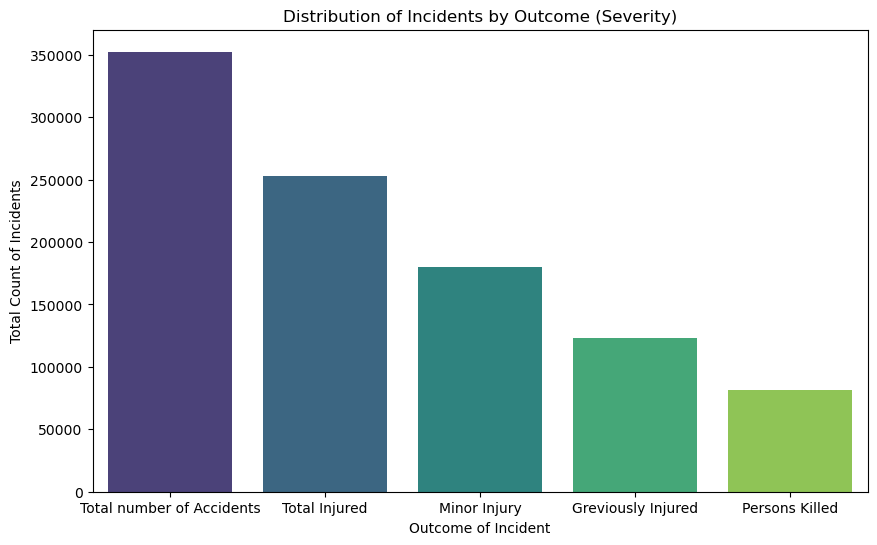

This plot shows the distribution of incidents based on their outcomes, which can be interpreted as different levels of severity.


In [15]:
outcome_counts = df.groupby('Outcome of Incident')['Count'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette='viridis')
plt.title('Distribution of Incidents by Outcome (Severity)')
plt.xlabel('Outcome of Incident')
plt.ylabel('Total Count of Incidents')
plt.show()
print("This plot shows the distribution of incidents based on their outcomes, which can be interpreted as different levels of severity.")

### --- Task 4: Geospatial Analysis of Incidents (Objective 4 adapted) ---

In [16]:
# Using 'Million Plus Cities' for geographical distribution and 'Count' for incidents.
print("\n--- Task 4: Geospatial Analysis of Incidents (Objective 4 adapted) ---")


--- Task 4: Geospatial Analysis of Incidents (Objective 4 adapted) ---


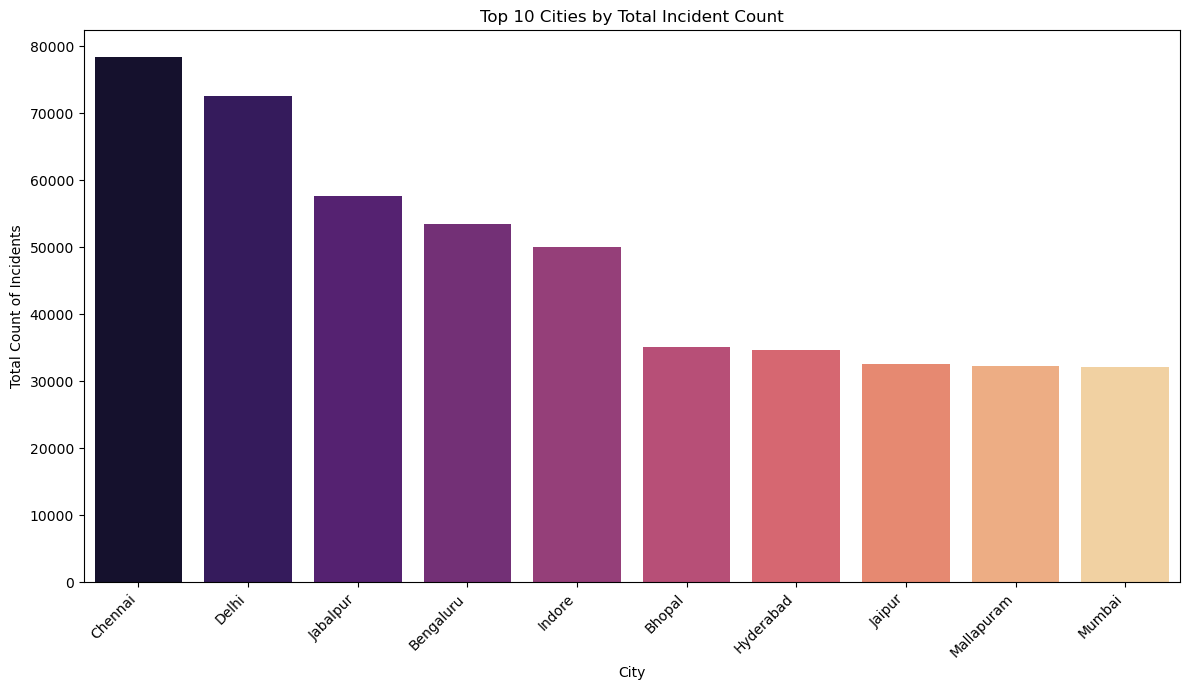

This plot identifies the top 10 cities with the highest number of reported incidents.


In [17]:
top_cities_incidents = df.groupby('Million Plus Cities')['Count'].sum().nlargest(10)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_cities_incidents.index, y=top_cities_incidents.values, palette='magma')
plt.title('Top 10 Cities by Total Incident Count')
plt.xlabel('City')
plt.ylabel('Total Count of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("This plot identifies the top 10 cities with the highest number of reported incidents.")

### --- Task 5: Key Factors Contributing to Incidents (Objective 2 adapted) ---

In [18]:
# Using 'Cause category' and 'Cause Subcategory' to understand contributing factors.
print("\n--- Task 5: Key Factors Contributing to Incidents (Objective 2 adapted) ---")


--- Task 5: Key Factors Contributing to Incidents (Objective 2 adapted) ---


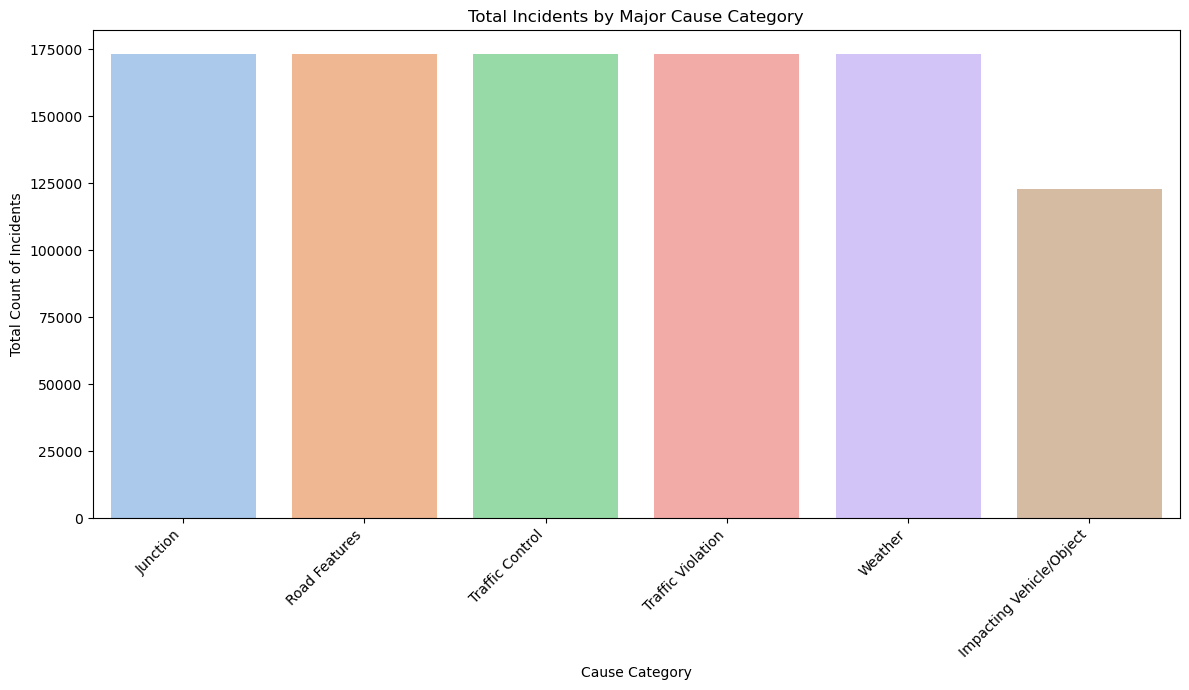

This plot shows the distribution of incidents across major cause categories.


In [19]:
# Incidents by Cause Category
cause_category_incidents = df.groupby('Cause category')['Count'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=cause_category_incidents.index, y=cause_category_incidents.values, palette='pastel')
plt.title('Total Incidents by Major Cause Category')
plt.xlabel('Cause Category')
plt.ylabel('Total Count of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("This plot shows the distribution of incidents across major cause categories.")

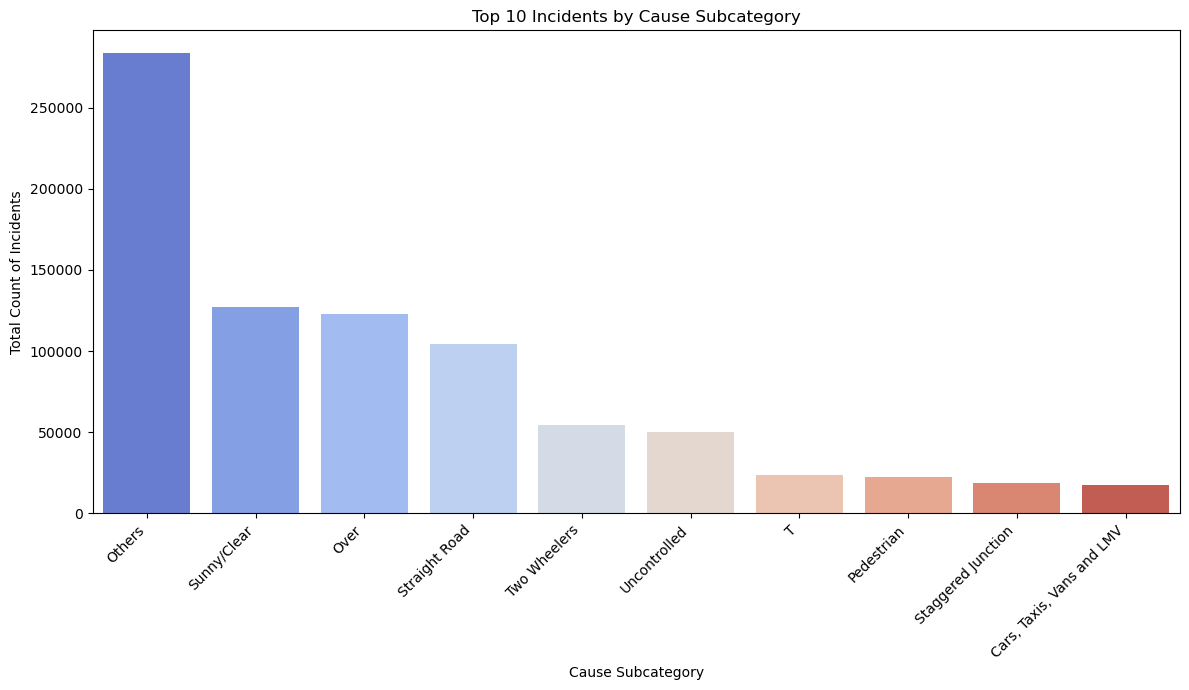

This plot details the top 10 specific cause subcategories contributing to incidents.


In [20]:
# Top 10 Incidents by Cause Subcategory
cause_subcategory_incidents = df.groupby('Cause Subcategory')['Count'].sum().nlargest(10)
plt.figure(figsize=(12, 7))
sns.barplot(x=cause_subcategory_incidents.index, y=cause_subcategory_incidents.values, palette='coolwarm')
plt.title('Top 10 Incidents by Cause Subcategory')
plt.xlabel('Cause Subcategory')
plt.ylabel('Total Count of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("This plot details the top 10 specific cause subcategories contributing to incidents.")

### --- Task 6: Combined Analysis of Outcome by Cause Category (Cross-analysis adapted) ---


--- Task 6: Combined Analysis of Outcome by Cause Category (Cross-analysis adapted) ---


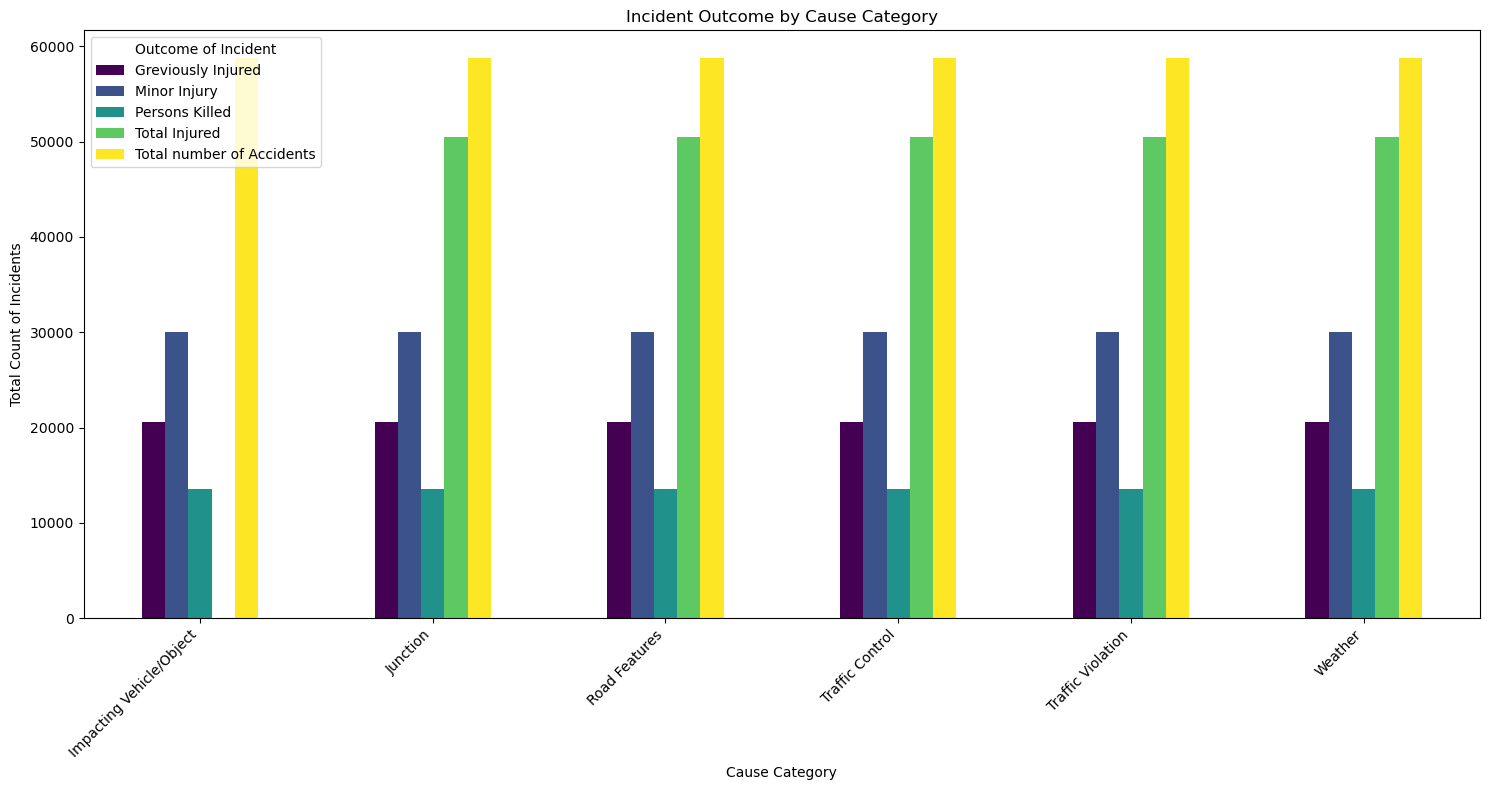

This stacked bar chart visualizes how different outcomes are distributed across various cause categories.


In [21]:
print("\n--- Task 6: Combined Analysis of Outcome by Cause Category (Cross-analysis adapted) ---")

outcome_by_cause_category = df.groupby(['Cause category', 'Outcome of Incident'])['Count'].sum().unstack(fill_value=0)
outcome_by_cause_category.plot(kind='bar', figsize=(15, 8), colormap='viridis')
plt.title('Incident Outcome by Cause Category')
plt.xlabel('Cause Category')
plt.ylabel('Total Count of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("This stacked bar chart visualizes how different outcomes are distributed across various cause categories.")